# Random Forest

#### Imports

In [29]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.rf_experiment import RandomForestExperiment
from src.utils import evaluate_model, save_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experimento 1: Conjunto com todas as Features

In [30]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### RF - Default

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_exp1 = RandomForestClassifier(n_estimators=100, random_state=14)
rf_exp1.fit(X_train_exp1, y_train_exp1)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== Métricas rf_def_exp1  ===
    Acurácia: 0.8041
    Precisão: 0.7819
    Recall:   0.7659
    F1-Score: 0.7727
    MCC:      0.5476
    AUC:      0.8686


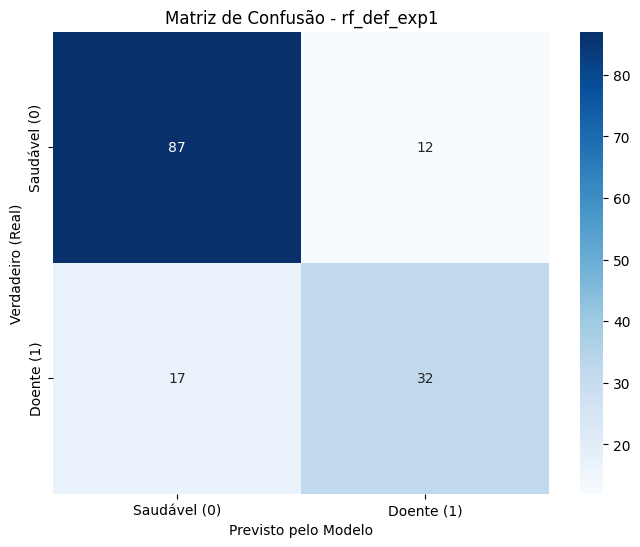

In [32]:
# Avaliar modelo
y_pred_def_exp1 = rf_exp1.predict(X_test_exp1)
y_prob_def_exp1 = rf_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'rf_def_exp1', caminho)

### RF - Melhorado

In [33]:
# Criar o experimento
experimento_1 = RandomForestExperiment(X_train_exp1, y_train_exp1, 'rf_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_rf = experimento_1.best_model

[I 2026-08-18 19:22:11,006] A new study created in memory with name: no-name-d3a054fb-6684-4e6b-b088-67fd6352d405


Iniciando otimização do cenário rf_otz_exp1.


Best trial: 0. Best value: 0.796187:   2%|▏         | 1/50 [00:12<10:10, 12.46s/it]

[I 2026-08-18 19:22:23,449] Trial 0 finished with value: 0.7961865975564605 and parameters: {'n_estimators': 92, 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7961865975564605.


Best trial: 0. Best value: 0.796187:   4%|▍         | 2/50 [00:22<08:36, 10.75s/it]

[I 2026-08-18 19:22:33,016] Trial 1 finished with value: 0.7780451684561274 and parameters: {'n_estimators': 270, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.7961865975564605.


Best trial: 2. Best value: 0.800753:   6%|▌         | 3/50 [00:32<08:12, 10.47s/it]

[I 2026-08-18 19:22:43,154] Trial 2 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 228, 'max_depth': 18, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:   8%|▊         | 4/50 [00:38<06:52,  8.97s/it]

[I 2026-08-18 19:22:49,814] Trial 3 finished with value: 0.778106873997285 and parameters: {'n_estimators': 65, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  10%|█         | 5/50 [00:39<04:24,  5.88s/it]

[I 2026-08-18 19:22:50,218] Trial 4 finished with value: 0.7963100086387757 and parameters: {'n_estimators': 186, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  12%|█▏        | 6/50 [00:39<03:00,  4.10s/it]

[I 2026-08-18 19:22:50,873] Trial 5 finished with value: 0.791558681969641 and parameters: {'n_estimators': 191, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  14%|█▍        | 7/50 [00:40<02:05,  2.92s/it]

[I 2026-08-18 19:22:51,353] Trial 6 finished with value: 0.791558681969641 and parameters: {'n_estimators': 226, 'max_depth': 11, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  16%|█▌        | 8/50 [00:41<01:32,  2.21s/it]

[I 2026-08-18 19:22:52,060] Trial 7 finished with value: 0.7871158830062939 and parameters: {'n_estimators': 252, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  18%|█▊        | 9/50 [00:41<01:11,  1.75s/it]

[I 2026-08-18 19:22:52,774] Trial 8 finished with value: 0.7870541774651363 and parameters: {'n_estimators': 244, 'max_depth': 8, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  20%|██        | 10/50 [00:42<00:54,  1.36s/it]

[I 2026-08-18 19:22:53,277] Trial 9 finished with value: 0.7780451684561274 and parameters: {'n_estimators': 115, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  22%|██▏       | 11/50 [00:43<00:46,  1.18s/it]

[I 2026-08-18 19:22:54,043] Trial 10 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 291, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 2. Best value: 0.800753:  24%|██▍       | 12/50 [00:44<00:42,  1.13s/it]

[I 2026-08-18 19:22:55,060] Trial 11 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 297, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.8007528076021226.


Best trial: 12. Best value: 0.805257:  26%|██▌       | 13/50 [00:45<00:41,  1.12s/it]

[I 2026-08-18 19:22:56,168] Trial 12 finished with value: 0.8052573121066272 and parameters: {'n_estimators': 292, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 12 with value: 0.8052573121066272.


Best trial: 13. Best value: 0.805319:  28%|██▊       | 14/50 [00:45<00:34,  1.05it/s]

[I 2026-08-18 19:22:56,712] Trial 13 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 147, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 13 with value: 0.8053190176477848.


Best trial: 14. Best value: 0.809824:  30%|███       | 15/50 [00:46<00:26,  1.31it/s]

[I 2026-08-18 19:22:57,063] Trial 14 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 147, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  32%|███▏      | 16/50 [00:46<00:21,  1.59it/s]

[I 2026-08-18 19:22:57,375] Trial 15 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 125, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  34%|███▍      | 17/50 [00:46<00:17,  1.93it/s]

[I 2026-08-18 19:22:57,635] Trial 16 finished with value: 0.800691102060965 and parameters: {'n_estimators': 155, 'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  36%|███▌      | 18/50 [00:46<00:14,  2.15it/s]

[I 2026-08-18 19:22:57,967] Trial 17 finished with value: 0.8008145131432803 and parameters: {'n_estimators': 153, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  38%|███▊      | 19/50 [00:47<00:14,  2.12it/s]

[I 2026-08-18 19:22:58,450] Trial 18 finished with value: 0.800691102060965 and parameters: {'n_estimators': 144, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  40%|████      | 20/50 [00:47<00:12,  2.37it/s]

[I 2026-08-18 19:22:58,759] Trial 19 finished with value: 0.8052573121066272 and parameters: {'n_estimators': 52, 'max_depth': 7, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  42%|████▏     | 21/50 [00:48<00:14,  2.04it/s]

[I 2026-08-18 19:22:59,412] Trial 20 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 208, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  44%|████▍     | 22/50 [00:48<00:14,  2.00it/s]

[I 2026-08-18 19:22:59,940] Trial 21 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 189, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  46%|████▌     | 23/50 [00:49<00:14,  1.89it/s]

[I 2026-08-18 19:23:00,529] Trial 22 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 209, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 14. Best value: 0.809824:  48%|████▊     | 24/50 [00:50<00:13,  1.94it/s]

[I 2026-08-18 19:23:01,016] Trial 23 finished with value: 0.7961865975564605 and parameters: {'n_estimators': 166, 'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 14 with value: 0.8098235221522893.


Best trial: 24. Best value: 0.809885:  50%|█████     | 25/50 [00:50<00:13,  1.89it/s]

[I 2026-08-18 19:23:01,573] Trial 24 finished with value: 0.8098852276934468 and parameters: {'n_estimators': 132, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  52%|█████▏    | 26/50 [00:50<00:11,  2.09it/s]

[I 2026-08-18 19:23:01,939] Trial 25 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 123, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  54%|█████▍    | 27/50 [00:51<00:10,  2.23it/s]

[I 2026-08-18 19:23:02,307] Trial 26 finished with value: 0.7963100086387757 and parameters: {'n_estimators': 97, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  56%|█████▌    | 28/50 [00:51<00:09,  2.36it/s]

[I 2026-08-18 19:23:02,682] Trial 27 finished with value: 0.8008145131432802 and parameters: {'n_estimators': 133, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  58%|█████▊    | 29/50 [00:52<00:08,  2.48it/s]

[I 2026-08-18 19:23:03,039] Trial 28 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 101, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  60%|██████    | 30/50 [00:52<00:07,  2.61it/s]

[I 2026-08-18 19:23:03,379] Trial 29 finished with value: 0.800691102060965 and parameters: {'n_estimators': 90, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  62%|██████▏   | 31/50 [00:52<00:07,  2.63it/s]

[I 2026-08-18 19:23:03,746] Trial 30 finished with value: 0.7963100086387757 and parameters: {'n_estimators': 103, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  64%|██████▍   | 32/50 [00:53<00:06,  2.72it/s]

[I 2026-08-18 19:23:04,084] Trial 31 finished with value: 0.8051956065654696 and parameters: {'n_estimators': 76, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  66%|██████▌   | 33/50 [00:53<00:06,  2.70it/s]

[I 2026-08-18 19:23:04,466] Trial 32 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 137, 'max_depth': 16, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  68%|██████▊   | 34/50 [00:53<00:05,  2.68it/s]

[I 2026-08-18 19:23:04,847] Trial 33 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 168, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  70%|███████   | 35/50 [00:54<00:04,  3.12it/s]

[I 2026-08-18 19:23:05,040] Trial 34 finished with value: 0.791682093051956 and parameters: {'n_estimators': 81, 'max_depth': 16, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  72%|███████▏  | 36/50 [00:54<00:05,  2.65it/s]

[I 2026-08-18 19:23:05,548] Trial 35 finished with value: 0.800691102060965 and parameters: {'n_estimators': 107, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  74%|███████▍  | 37/50 [00:55<00:05,  2.36it/s]

[I 2026-08-18 19:23:06,080] Trial 36 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 134, 'max_depth': 12, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  76%|███████▌  | 38/50 [00:55<00:05,  2.36it/s]

[I 2026-08-18 19:23:06,504] Trial 37 finished with value: 0.8008762186844378 and parameters: {'n_estimators': 118, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  78%|███████▊  | 39/50 [00:56<00:05,  2.17it/s]

[I 2026-08-18 19:23:07,057] Trial 38 finished with value: 0.791682093051956 and parameters: {'n_estimators': 179, 'max_depth': 14, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  80%|████████  | 40/50 [00:56<00:04,  2.40it/s]

[I 2026-08-18 19:23:07,362] Trial 39 finished with value: 0.8053807231889424 and parameters: {'n_estimators': 62, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  82%|████████▏ | 41/50 [00:56<00:03,  2.41it/s]

[I 2026-08-18 19:23:07,773] Trial 40 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 88, 'max_depth': 19, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  84%|████████▍ | 42/50 [00:57<00:03,  2.46it/s]

[I 2026-08-18 19:23:08,164] Trial 41 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 166, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  86%|████████▌ | 43/50 [00:57<00:02,  2.36it/s]

[I 2026-08-18 19:23:08,627] Trial 42 finished with value: 0.791682093051956 and parameters: {'n_estimators': 171, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  88%|████████▊ | 44/50 [00:58<00:02,  2.13it/s]

[I 2026-08-18 19:23:09,197] Trial 43 finished with value: 0.8098235221522893 and parameters: {'n_estimators': 134, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  90%|█████████ | 45/50 [00:58<00:02,  2.19it/s]

[I 2026-08-18 19:23:09,633] Trial 44 finished with value: 0.7825496729606319 and parameters: {'n_estimators': 157, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  92%|█████████▏| 46/50 [00:58<00:01,  2.42it/s]

[I 2026-08-18 19:23:09,939] Trial 45 finished with value: 0.8053190176477848 and parameters: {'n_estimators': 142, 'max_depth': 18, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  94%|█████████▍| 47/50 [00:59<00:01,  2.42it/s]

[I 2026-08-18 19:23:10,357] Trial 46 finished with value: 0.7825496729606319 and parameters: {'n_estimators': 109, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  96%|█████████▌| 48/50 [00:59<00:00,  2.25it/s]

[I 2026-08-18 19:23:10,872] Trial 47 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 205, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885:  98%|█████████▊| 49/50 [01:00<00:00,  1.92it/s]

[I 2026-08-18 19:23:11,570] Trial 48 finished with value: 0.8052573121066272 and parameters: {'n_estimators': 179, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 24 with value: 0.8098852276934468.


Best trial: 24. Best value: 0.809885: 100%|██████████| 50/50 [01:00<00:00,  1.22s/it]


[I 2026-08-18 19:23:11,955] Trial 49 finished with value: 0.8007528076021226 and parameters: {'n_estimators': 126, 'max_depth': 19, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 24 with value: 0.8098852276934468.
Melhor pontuação (CV): 0.8099
Melhores parâmetros:
{'n_estimators': 132, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'entropy'}


In [34]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
      feature  importance
  eosinophils      0.1210
  lymphocytes      0.1199
    platelets      0.0750
 lymphocytesP      0.0652
 eosinophilsP      0.0632
   leukocytes      0.0526
 neutrophilsP      0.0469
         mchc      0.0406
  neutrophils      0.0387
  hematocritP      0.0384
    basophils      0.0346
          mpv      0.0346
redbloodcells      0.0326
         rdwP      0.0316
    monocytes      0.0314
   basophilsP      0.0308
          mcv      0.0303
   monocytesP      0.0298
          age      0.0273
          mch      0.0260
   hemoglobin      0.0259
      sex_bin      0.0036


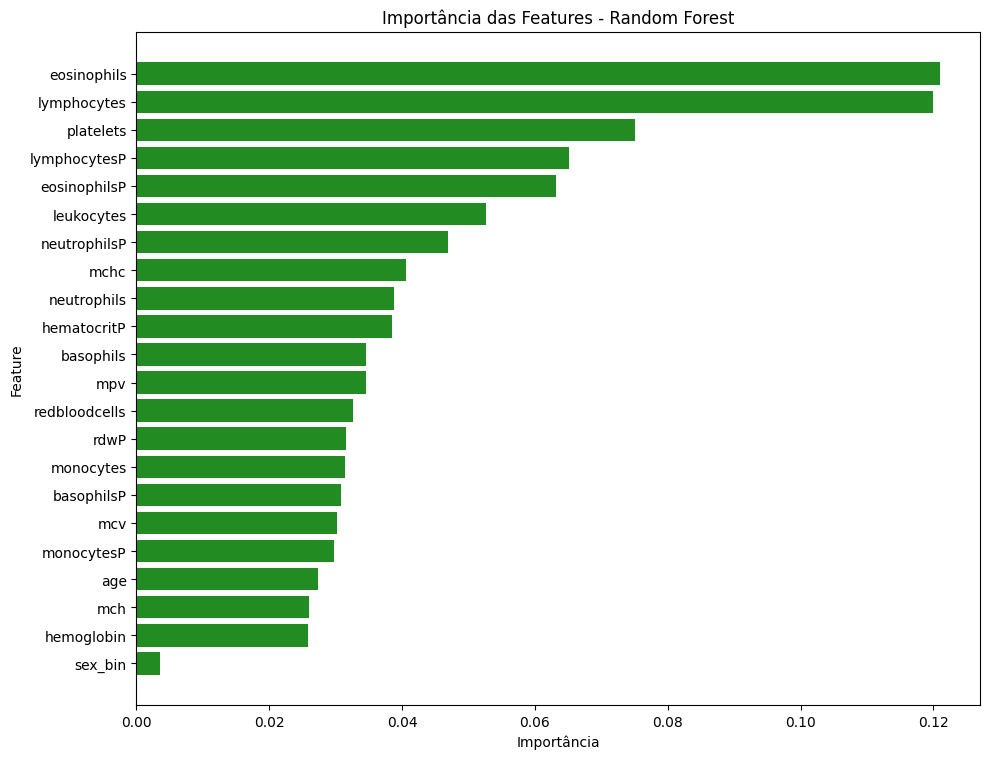

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Importância das features do Random Forest
feature_importance = pd.DataFrame({
    'feature': X_train_exp1.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print('=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===')
print(feature_importance.round(4).to_string(index=False))

plt.figure(figsize=(10, max(6, 0.35 * len(feature_importance))))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='forestgreen')
plt.title('Importância das Features - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

=== Métricas rf_otz_exp1  ===
    Acurácia: 0.7905
    Precisão: 0.7675
    Recall:   0.7455
    F1-Score: 0.7541
    MCC:      0.5126
    AUC:      0.8633


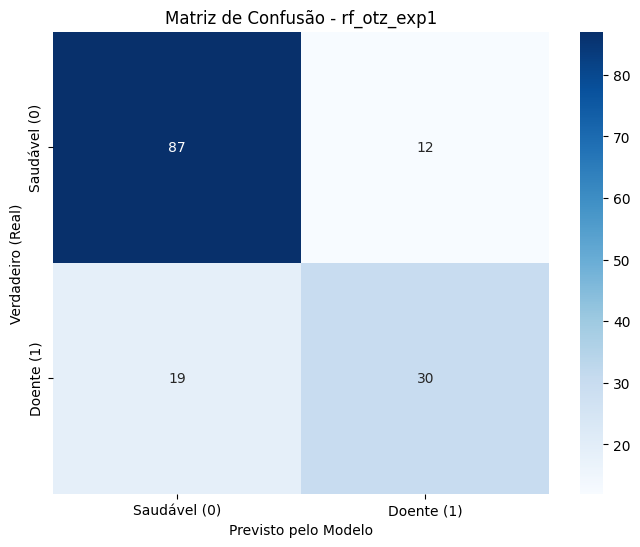

In [36]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'rf_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [37]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### RF - Default

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_exp2 = RandomForestClassifier(n_estimators=100, random_state=14)
rf_exp2.fit(X_train_exp2, y_train_exp2)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


=== Métricas rf_def_exp2  ===
    Acurácia: 0.7770
    Precisão: 0.7553
    Recall:   0.7200
    F1-Score: 0.7314
    MCC:      0.4739
    AUC:      0.8289


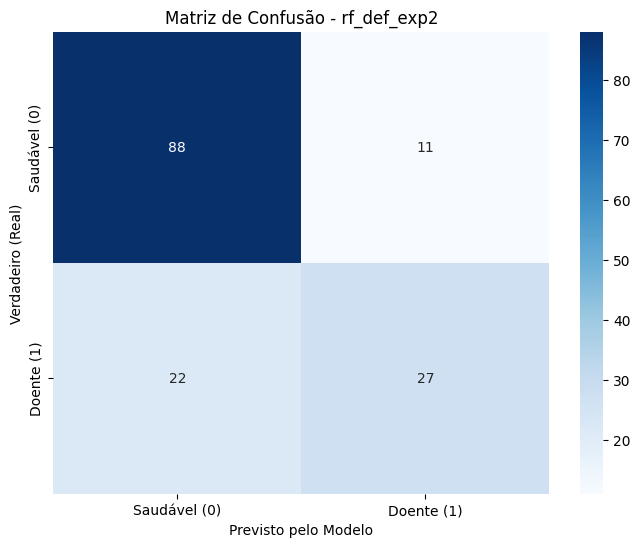

In [39]:
# Avaliar modelo
y_pred_def_exp2 = rf_exp2.predict(X_test_exp2)
y_prob_def_exp2 = rf_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'rf_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'rf_def_exp2', caminho)

### RF - Melhorado

In [40]:
# Criar o experimento
experimento_2 = RandomForestExperiment(X_train_exp2, y_train_exp2, 'rf_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:23:20,175] A new study created in memory with name: no-name-9f1f035d-b39b-4da0-b17f-98bf98e3d810


Iniciando otimização do cenário rf_otz_exp2.


Best trial: 0. Best value: 0.732877:   2%|▏         | 1/50 [00:00<00:29,  1.65it/s]

[I 2026-08-18 19:23:20,797] Trial 0 finished with value: 0.7328767123287672 and parameters: {'n_estimators': 186, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7328767123287672.


Best trial: 1. Best value: 0.742071:   4%|▍         | 2/50 [00:01<00:24,  1.97it/s]

[I 2026-08-18 19:23:21,230] Trial 1 finished with value: 0.7420708379612488 and parameters: {'n_estimators': 140, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 1 with value: 0.7420708379612488.


Best trial: 2. Best value: 0.74639:   6%|▌         | 3/50 [00:01<00:30,  1.56it/s] 

[I 2026-08-18 19:23:22,031] Trial 2 finished with value: 0.7463902258422807 and parameters: {'n_estimators': 276, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 2 with value: 0.7463902258422807.


Best trial: 2. Best value: 0.74639:   8%|▊         | 4/50 [00:02<00:27,  1.69it/s]

[I 2026-08-18 19:23:22,556] Trial 3 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 178, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 2 with value: 0.7463902258422807.


Best trial: 2. Best value: 0.74639:  10%|█         | 5/50 [00:02<00:23,  1.90it/s]

[I 2026-08-18 19:23:22,960] Trial 4 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 126, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.7463902258422807.


Best trial: 2. Best value: 0.74639:  12%|█▏        | 6/50 [00:06<01:04,  1.46s/it]

[I 2026-08-18 19:23:26,222] Trial 5 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 272, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 2 with value: 0.7463902258422807.


Best trial: 6. Best value: 0.746575:  14%|█▍        | 7/50 [00:06<00:54,  1.27s/it]

[I 2026-08-18 19:23:27,103] Trial 6 finished with value: 0.7465753424657534 and parameters: {'n_estimators': 118, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  16%|█▌        | 8/50 [00:08<00:55,  1.33s/it]

[I 2026-08-18 19:23:28,551] Trial 7 finished with value: 0.7283722078242626 and parameters: {'n_estimators': 246, 'max_depth': 17, 'min_samples_split': 5, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  18%|█▊        | 9/50 [00:10<01:03,  1.56s/it]

[I 2026-08-18 19:23:30,611] Trial 8 finished with value: 0.7238677033197581 and parameters: {'n_estimators': 278, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  20%|██        | 10/50 [00:11<00:50,  1.26s/it]

[I 2026-08-18 19:23:31,227] Trial 9 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 147, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  22%|██▏       | 11/50 [00:11<00:38,  1.01it/s]

[I 2026-08-18 19:23:31,576] Trial 10 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 51, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  24%|██▍       | 12/50 [00:11<00:30,  1.23it/s]

[I 2026-08-18 19:23:32,007] Trial 11 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 77, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  26%|██▌       | 13/50 [00:12<00:29,  1.24it/s]

[I 2026-08-18 19:23:32,807] Trial 12 finished with value: 0.7238059977786006 and parameters: {'n_estimators': 225, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  28%|██▊       | 14/50 [00:13<00:27,  1.33it/s]

[I 2026-08-18 19:23:33,416] Trial 13 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 220, 'max_depth': 20, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  30%|███       | 15/50 [00:13<00:23,  1.46it/s]

[I 2026-08-18 19:23:33,949] Trial 14 finished with value: 0.7419474268789337 and parameters: {'n_estimators': 101, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  32%|███▏      | 16/50 [00:15<00:30,  1.11it/s]

[I 2026-08-18 19:23:35,352] Trial 15 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 293, 'max_depth': 14, 'min_samples_split': 10, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  34%|███▍      | 17/50 [00:15<00:25,  1.31it/s]

[I 2026-08-18 19:23:35,801] Trial 16 finished with value: 0.7375663334567443 and parameters: {'n_estimators': 99, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 6. Best value: 0.746575:  36%|███▌      | 18/50 [00:16<00:24,  1.30it/s]

[I 2026-08-18 19:23:36,573] Trial 17 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 6 with value: 0.7465753424657534.


Best trial: 18. Best value: 0.75108:  38%|███▊      | 19/50 [00:17<00:25,  1.23it/s]

[I 2026-08-18 19:23:37,499] Trial 18 finished with value: 0.7510798469702579 and parameters: {'n_estimators': 157, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  40%|████      | 20/50 [00:18<00:27,  1.11it/s]

[I 2026-08-18 19:23:38,603] Trial 19 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 161, 'max_depth': 6, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  42%|████▏     | 21/50 [00:19<00:30,  1.04s/it]

[I 2026-08-18 19:23:39,958] Trial 20 finished with value: 0.7420708379612488 and parameters: {'n_estimators': 114, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  44%|████▍     | 22/50 [00:21<00:32,  1.15s/it]

[I 2026-08-18 19:23:41,373] Trial 21 finished with value: 0.7420091324200913 and parameters: {'n_estimators': 155, 'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  46%|████▌     | 23/50 [00:22<00:34,  1.29s/it]

[I 2026-08-18 19:23:42,978] Trial 22 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 205, 'max_depth': 4, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  48%|████▊     | 24/50 [00:24<00:34,  1.34s/it]

[I 2026-08-18 19:23:44,423] Trial 23 finished with value: 0.7419474268789337 and parameters: {'n_estimators': 249, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  50%|█████     | 25/50 [00:24<00:27,  1.10s/it]

[I 2026-08-18 19:23:44,984] Trial 24 finished with value: 0.7329384178699246 and parameters: {'n_estimators': 76, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  52%|█████▏    | 26/50 [00:25<00:24,  1.01s/it]

[I 2026-08-18 19:23:45,762] Trial 25 finished with value: 0.7419474268789337 and parameters: {'n_estimators': 125, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  54%|█████▍    | 27/50 [00:26<00:21,  1.09it/s]

[I 2026-08-18 19:23:46,506] Trial 26 finished with value: 0.7330618289522399 and parameters: {'n_estimators': 169, 'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  56%|█████▌    | 28/50 [00:26<00:17,  1.24it/s]

[I 2026-08-18 19:23:47,033] Trial 27 finished with value: 0.7420708379612488 and parameters: {'n_estimators': 140, 'max_depth': 7, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  58%|█████▊    | 29/50 [00:27<00:14,  1.47it/s]

[I 2026-08-18 19:23:47,404] Trial 28 finished with value: 0.7420708379612488 and parameters: {'n_estimators': 82, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  60%|██████    | 30/50 [00:28<00:18,  1.09it/s]

[I 2026-08-18 19:23:48,889] Trial 29 finished with value: 0.7328767123287672 and parameters: {'n_estimators': 183, 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'criterion': 'entropy'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  62%|██████▏   | 31/50 [00:29<00:15,  1.19it/s]

[I 2026-08-18 19:23:49,567] Trial 30 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 201, 'max_depth': 18, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  64%|██████▍   | 32/50 [00:30<00:14,  1.26it/s]

[I 2026-08-18 19:23:50,242] Trial 31 finished with value: 0.7510181414291003 and parameters: {'n_estimators': 199, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  66%|██████▌   | 33/50 [00:30<00:12,  1.39it/s]

[I 2026-08-18 19:23:50,789] Trial 32 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 201, 'max_depth': 18, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  68%|██████▊   | 34/50 [00:31<00:10,  1.47it/s]

[I 2026-08-18 19:23:51,388] Trial 33 finished with value: 0.7420091324200913 and parameters: {'n_estimators': 225, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  70%|███████   | 35/50 [00:31<00:09,  1.59it/s]

[I 2026-08-18 19:23:51,890] Trial 34 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 190, 'max_depth': 18, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  72%|███████▏  | 36/50 [00:32<00:08,  1.73it/s]

[I 2026-08-18 19:23:52,359] Trial 35 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 166, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  74%|███████▍  | 37/50 [00:32<00:07,  1.75it/s]

[I 2026-08-18 19:23:52,890] Trial 36 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 126, 'max_depth': 16, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  76%|███████▌  | 38/50 [00:34<00:09,  1.21it/s]

[I 2026-08-18 19:23:54,326] Trial 37 finished with value: 0.7463902258422807 and parameters: {'n_estimators': 239, 'max_depth': 19, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  78%|███████▊  | 39/50 [00:34<00:09,  1.20it/s]

[I 2026-08-18 19:23:55,177] Trial 38 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 182, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  80%|████████  | 40/50 [00:35<00:08,  1.21it/s]

[I 2026-08-18 19:23:55,961] Trial 39 finished with value: 0.7328150067876096 and parameters: {'n_estimators': 137, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  82%|████████▏ | 41/50 [00:37<00:08,  1.05it/s]

[I 2026-08-18 19:23:57,240] Trial 40 finished with value: 0.7510798469702579 and parameters: {'n_estimators': 209, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  84%|████████▍ | 42/50 [00:37<00:07,  1.13it/s]

[I 2026-08-18 19:23:57,961] Trial 41 finished with value: 0.7420091324200913 and parameters: {'n_estimators': 215, 'max_depth': 14, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  86%|████████▌ | 43/50 [00:38<00:05,  1.18it/s]

[I 2026-08-18 19:23:58,709] Trial 42 finished with value: 0.7373812168332717 and parameters: {'n_estimators': 238, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  88%|████████▊ | 44/50 [00:39<00:05,  1.17it/s]

[I 2026-08-18 19:23:59,571] Trial 43 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 193, 'max_depth': 17, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  90%|█████████ | 45/50 [00:42<00:07,  1.42s/it]

[I 2026-08-18 19:24:02,317] Trial 44 finished with value: 0.7419474268789337 and parameters: {'n_estimators': 210, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  92%|█████████▏| 46/50 [00:42<00:04,  1.25s/it]

[I 2026-08-18 19:24:03,180] Trial 45 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 176, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 18. Best value: 0.75108:  94%|█████████▍| 47/50 [00:44<00:04,  1.42s/it]

[I 2026-08-18 19:24:04,988] Trial 46 finished with value: 0.7465136369245959 and parameters: {'n_estimators': 260, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': 'log2', 'criterion': 'gini'}. Best is trial 18 with value: 0.7510798469702579.


Best trial: 47. Best value: 0.751142:  96%|█████████▌| 48/50 [00:45<00:02,  1.34s/it]

[I 2026-08-18 19:24:06,158] Trial 47 finished with value: 0.7511415525114155 and parameters: {'n_estimators': 146, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 47 with value: 0.7511415525114155.


Best trial: 47. Best value: 0.751142:  98%|█████████▊| 49/50 [00:46<00:01,  1.12s/it]

[I 2026-08-18 19:24:06,779] Trial 48 finished with value: 0.7374429223744293 and parameters: {'n_estimators': 152, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 47 with value: 0.7511415525114155.


Best trial: 47. Best value: 0.751142: 100%|██████████| 50/50 [00:47<00:00,  1.06it/s]


[I 2026-08-18 19:24:07,377] Trial 49 finished with value: 0.7465753424657534 and parameters: {'n_estimators': 109, 'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 47 with value: 0.7511415525114155.
Melhor pontuação (CV): 0.7511
Melhores parâmetros:
{'n_estimators': 146, 'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'criterion': 'gini'}


In [41]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas rf_otz_exp2  ===
    Acurácia: 0.7838
    Precisão: 0.7803
    Recall:   0.7095
    F1-Score: 0.7259
    MCC:      0.4847
    AUC:      0.8407


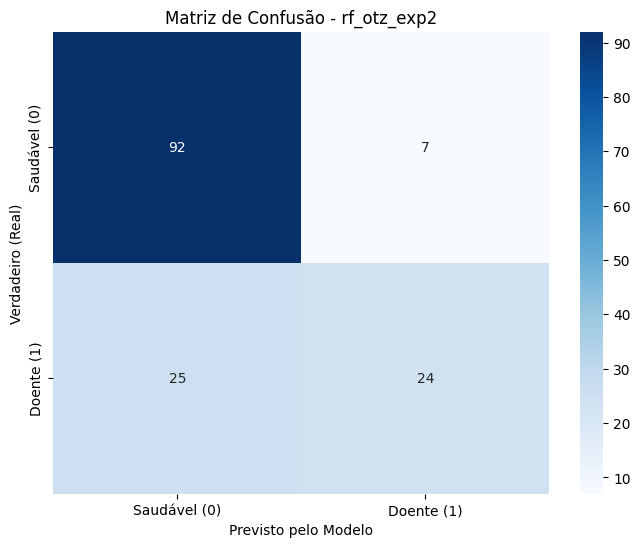

In [42]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'rf_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'rf_otz_exp2', caminho)